In [1]:
import pandas as pd
import numpy as np
from matplotlib import dates
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import gridspec

matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'NanumGothic'

data = pd.read_csv('2016_2020.csv')
data['REG_DTIME'] = pd.to_datetime(data['REG_DTIME'])
data['year'] = data['REG_DTIME'].dt.year
data['month'] = data['REG_DTIME'].dt.month
data['day'] = data['REG_DTIME'].dt.day

In [2]:
data['h_dong'].unique()

array(['석사동', '신동면', '강남동', '서  면', '남  면', '사북면', '동내면', '효자1동', '남산면',
       '근화동', '신사우동', '신북읍', '소양동', '약사명동', '동  면', '후평1동', '퇴계동', '북산면',
       '조운동', '동산면', '교  동'], dtype=object)

In [3]:
def year_df_sum(df , year):
    df = df[df['year'] == year] 
    arg_df = df.groupby(['year','month','day', 'h_dong']).sum()
    arg_df = arg_df.reset_index(level=['year','month','day','h_dong'])
    return arg_df

def year_df_mean(df , year):
    df = df[df['year'] == year] 
    arg_df = df.groupby(['year','month','day', 'h_dong']).mean()
    arg_df = arg_df.reset_index(level=['year','month','day','h_dong'])
    return arg_df

In [4]:
def get_col_heatmap(arg_df, col,year):
    heat_df = pd.DataFrame()

    for dong in data['h_dong'].unique():
        heat_df[dong] = arg_df[arg_df['h_dong'] == dong][col].to_list()
    dt = pd.date_range(f'{year}/1/1', f'{year}/12/31', freq='d')
    
    if len(heat_df.index) != len(dt):
        heat_df = heat_df[:-1]
    heat_df.index = pd.date_range(f'{year}/1/1', f'{year}/12/31', freq='d')
    

    fig = plt.figure(figsize=(25, 40))
    gs = gridspec.GridSpec(nrows=4, # row 몇 개 
                           ncols=1, # col 몇 개 
                           height_ratios=[1,1,1,1], 
                           width_ratios=[1])
    gs.update(wspace=0.1, hspace=0.4)
    
    for i in range(4):
        ax = plt.subplot(gs[i,0])
        heat_s = heat_df[i*90 : (i+1)*90].T
        ax.set_title(f' {col} columns heatmap  {str(heat_s.columns[0])[:-8]} ~ {str(heat_s.columns[-1])[:-8]}' , fontsize = 20)
        ax.set_yticks(range(len(heat_s.index)),heat_s.index , fontsize = 10)
        ax.set_xticks(range(len(heat_s.columns)),heat_s.columns , fontsize = 10,rotation=45 )
        
        cb = ax.pcolor(heat_s , cmap=matplotlib.cm.Blues)
        plt.colorbar(cb)
        

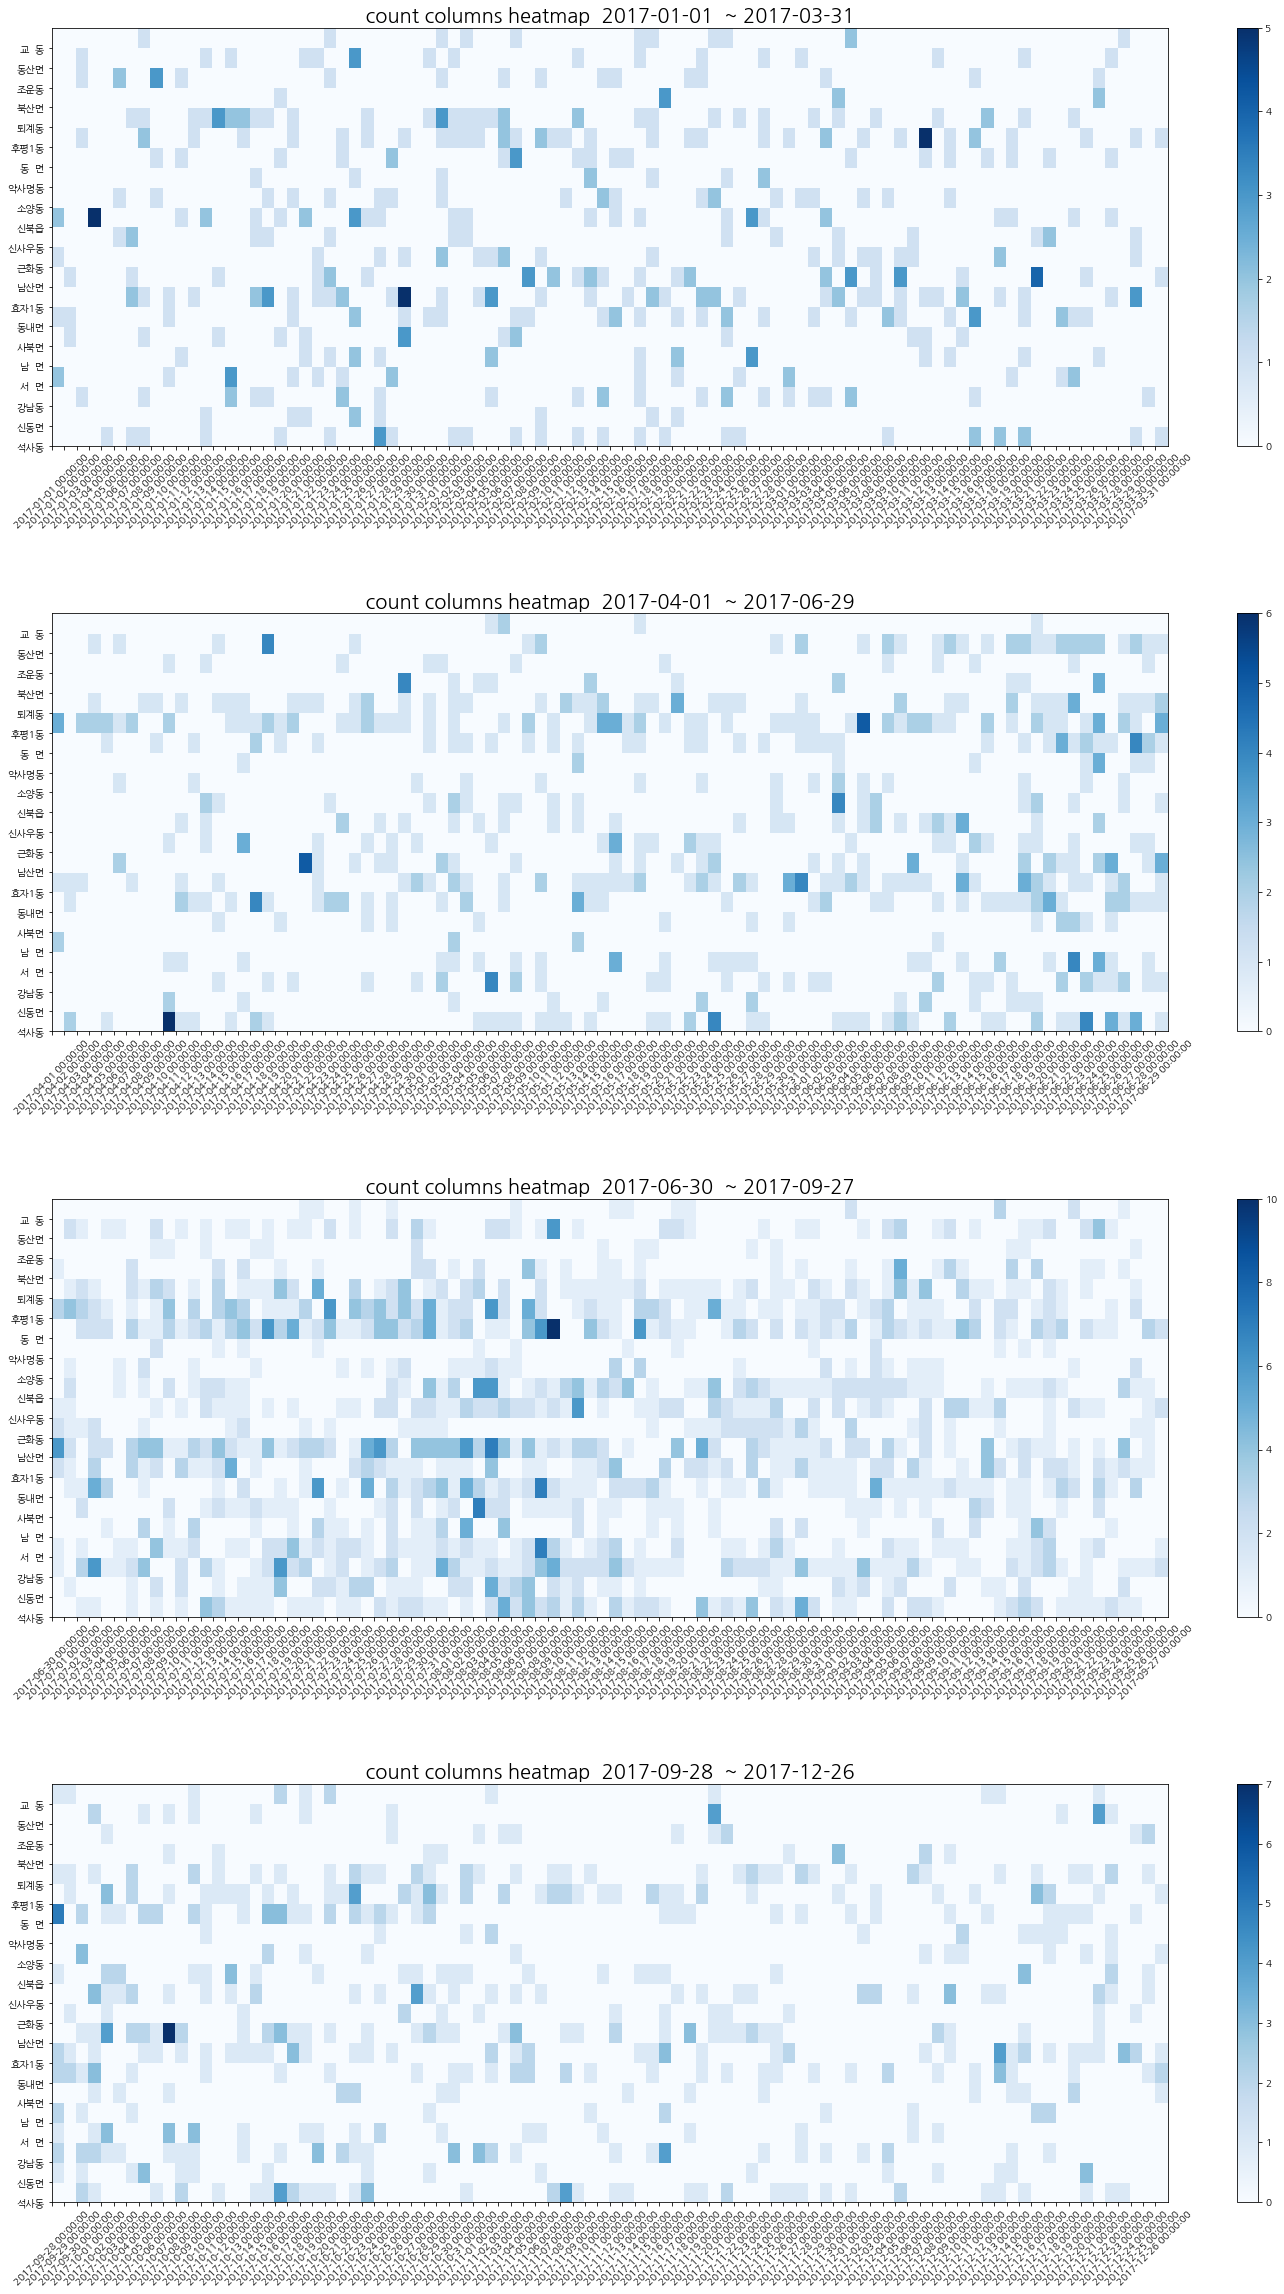

In [5]:
y_df = year_df_sum(data , 2017)
get_col_heatmap(y_df, 'count' , 2017)

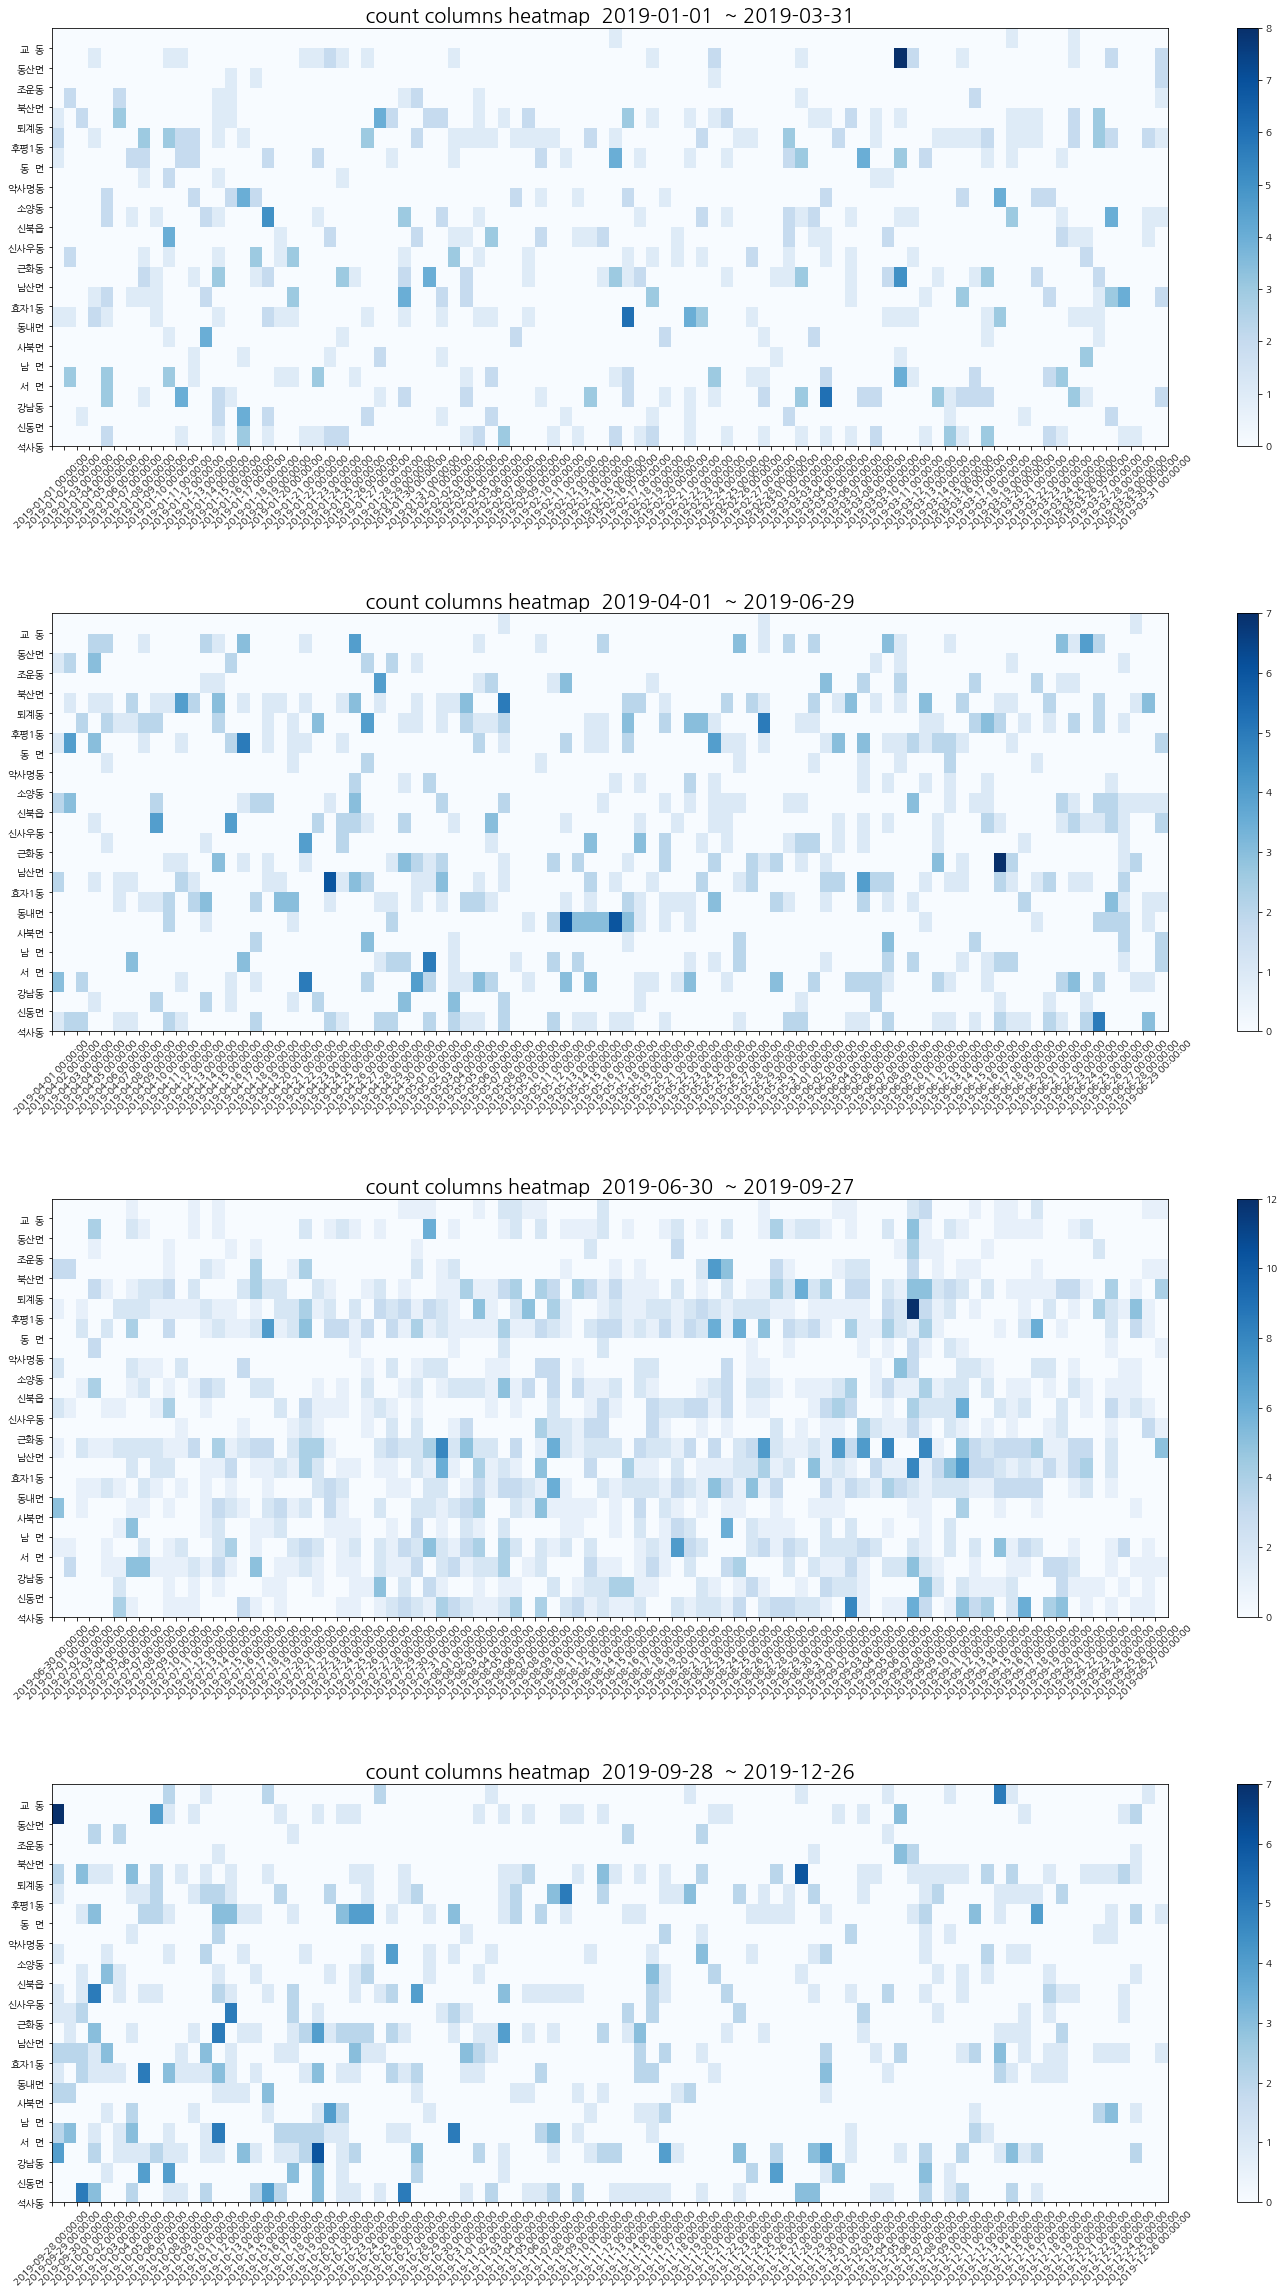

In [6]:
y_df = year_df_sum(data , 2019)
get_col_heatmap(y_df, 'count' , 2019)

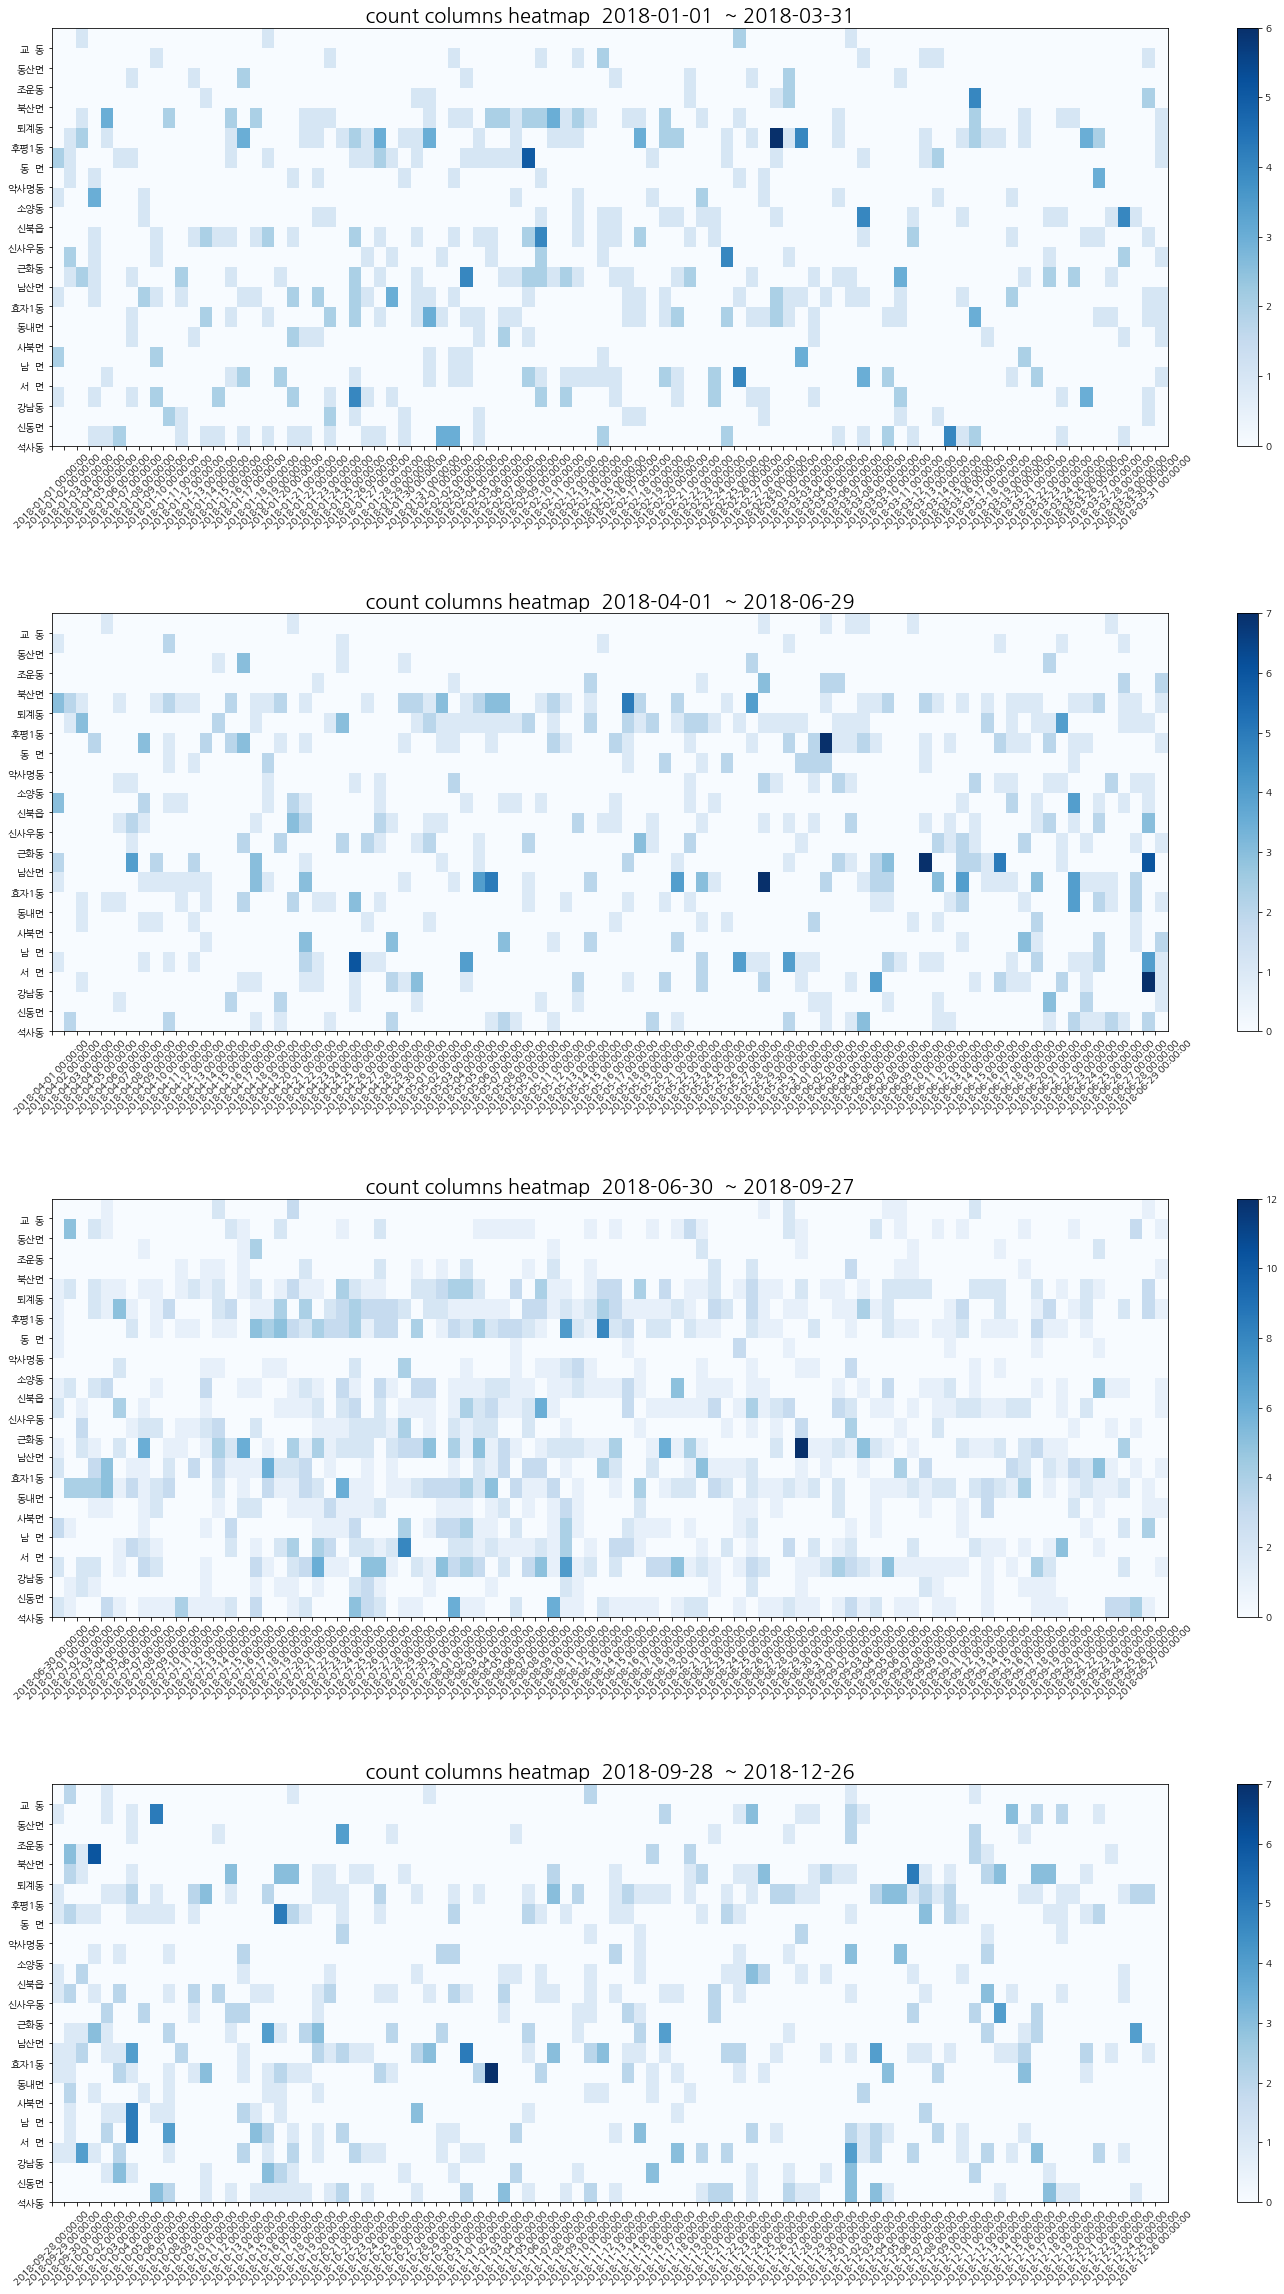

In [7]:
y_df = year_df_sum(data , 2018)
get_col_heatmap(y_df, 'count' , 2018)

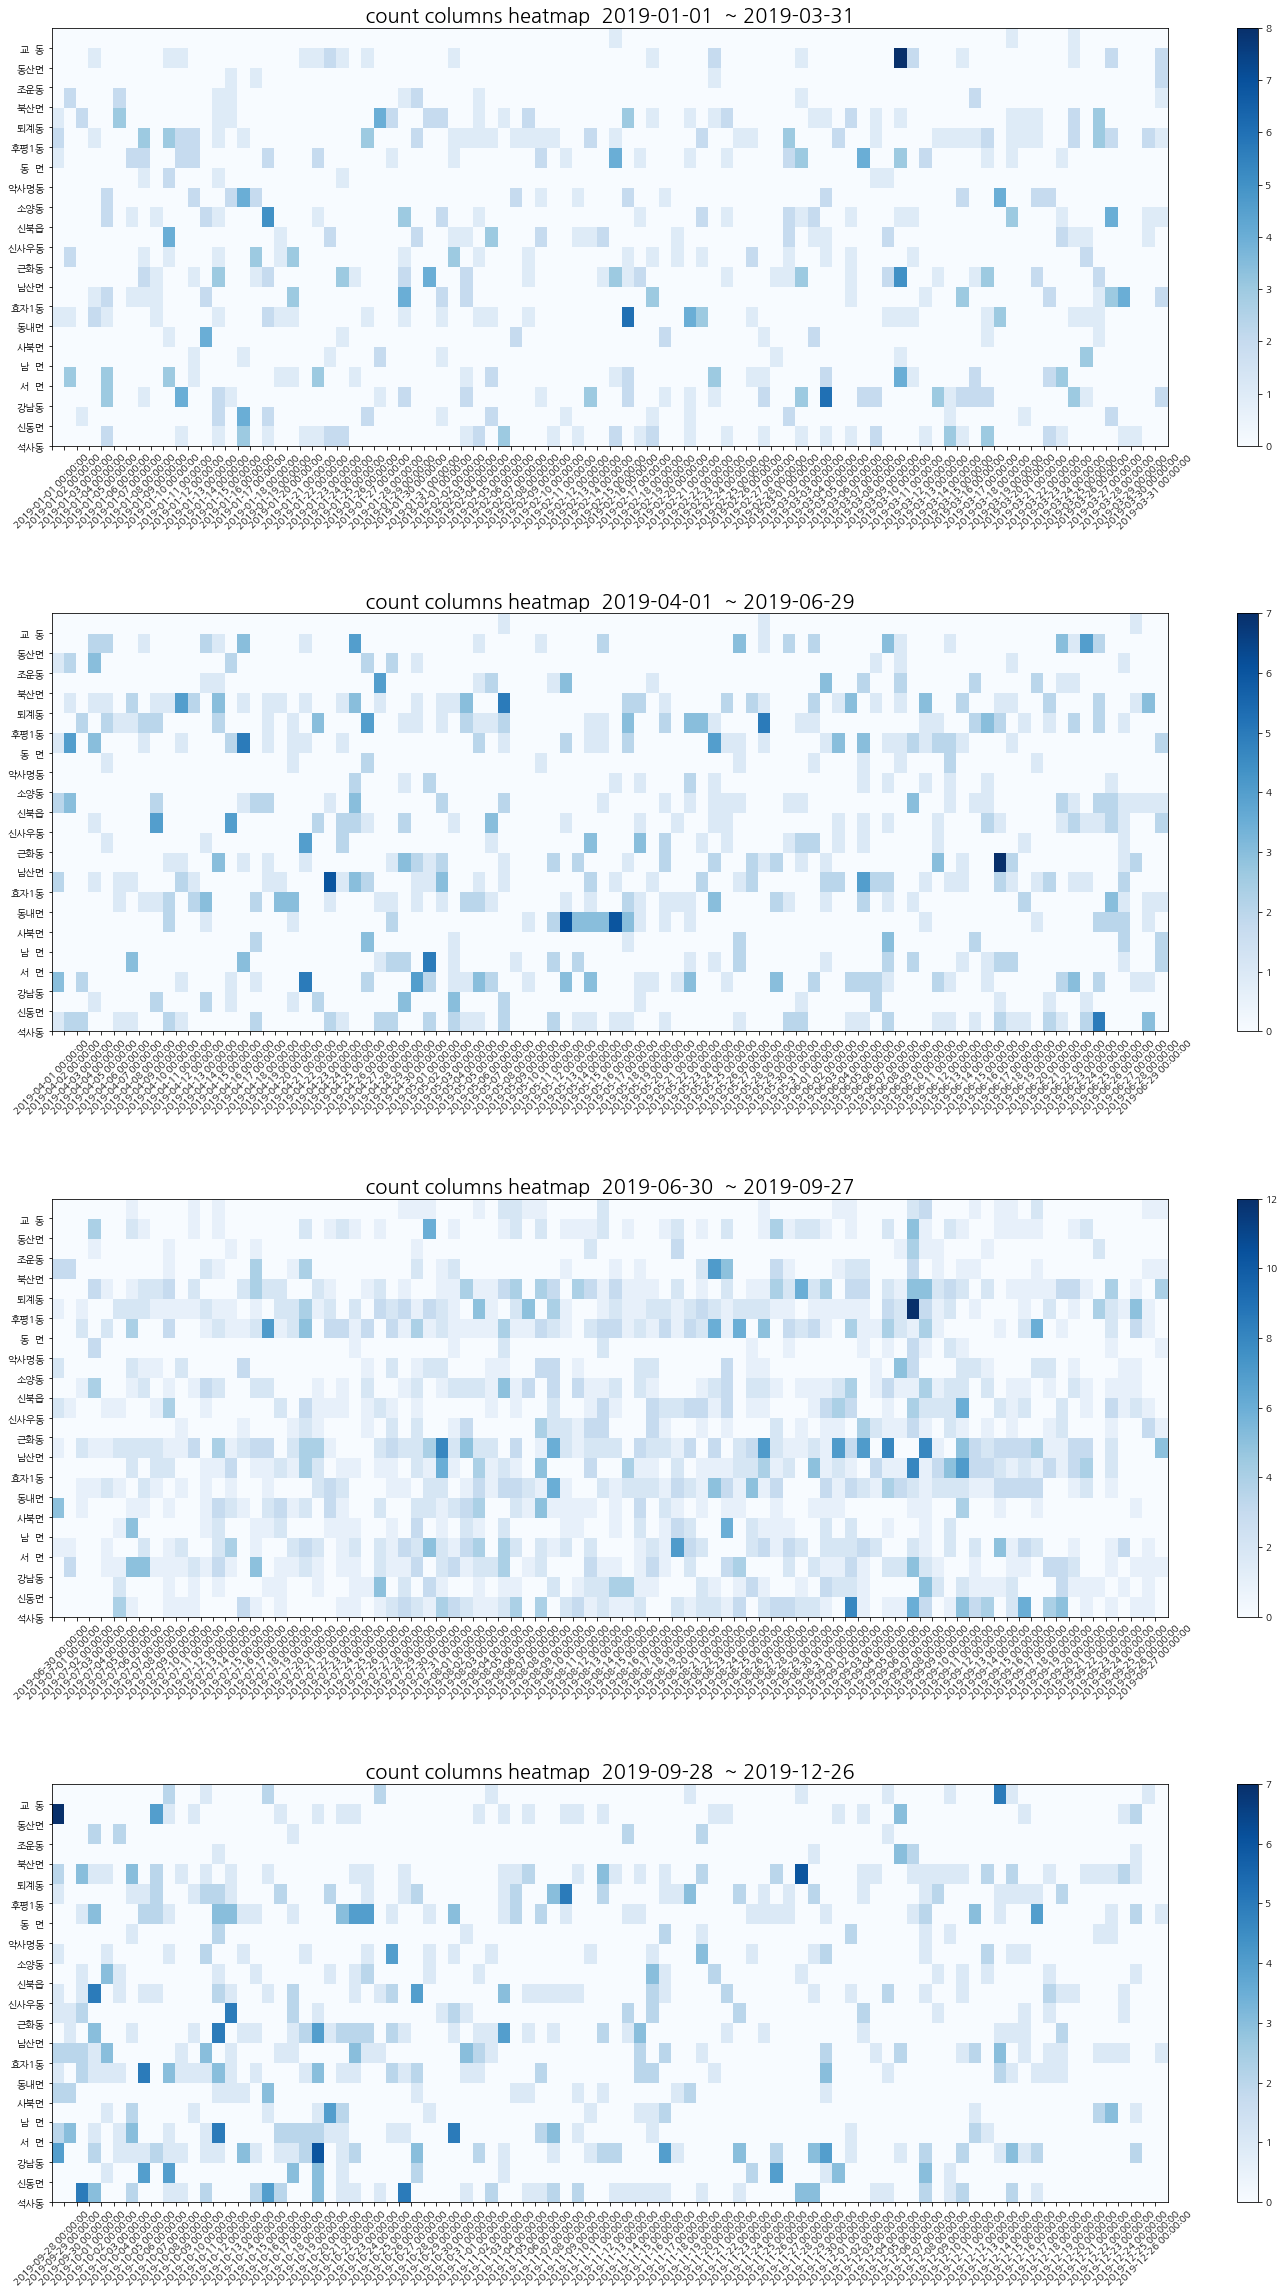

In [8]:
y_df = year_df_sum(data , 2019)
get_col_heatmap(y_df, 'count' , 2019)

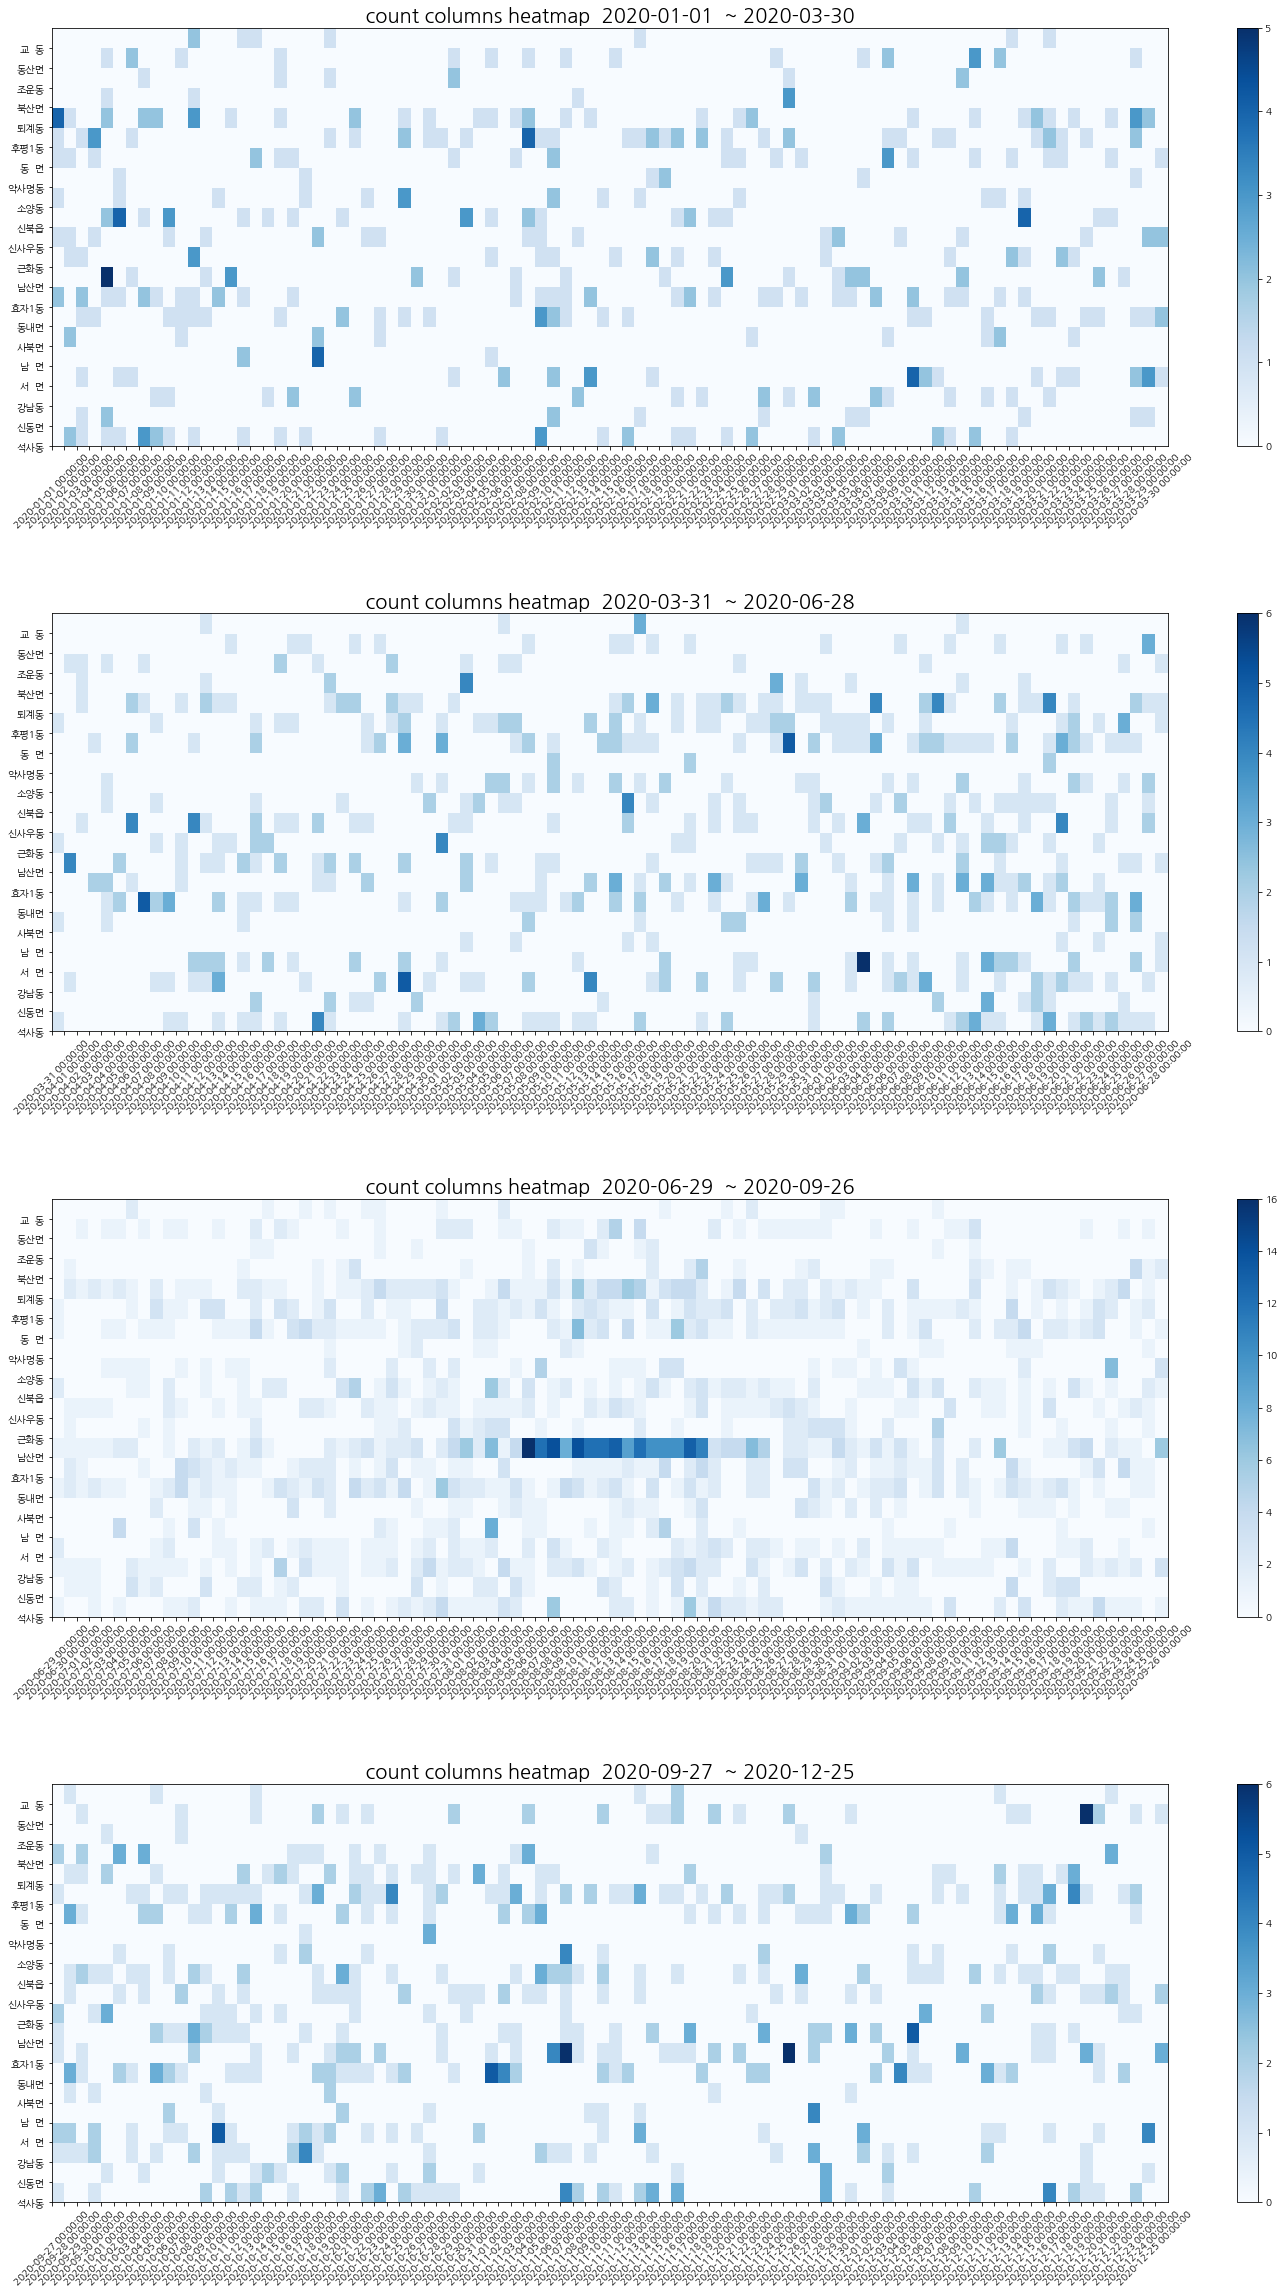

In [9]:
y_df = year_df_sum(data , 2020)
get_col_heatmap(y_df, 'count' , 2020)